# Final Notebook
## AI Dependency, Career Anxiety, and Student Burnout Analysis

Student: Hasrat Buttar\
Student Number: 301554205\
Course: IAT 461

### Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [28]:
df = pd.read_csv("ai_dependency_career_anxiety_students.csv")

### Preview Dataset

In [29]:
df.head()

,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
0,STU_00001,25,Male,B.Tech/B.E.,Engineering (Non-CS),3,Tier 3,Rural,0.3,Perplexity,...,3.5,8.7,2,1.5,8.5,1,3,6,0.0,9.09
1,STU_00002,20,Female,B.Tech/B.E.,Engineering (Non-CS),4,Tier 3,Urban,1.9,ChatGPT,...,2.4,8.2,3,4.2,8.3,4,5,3,0.0,6.03
2,STU_00003,25,Female,MBA,CS/IT,1,Tier 3,Urban,3.6,Gemini,...,2.3,16.4,1,2.3,7.0,5,9,3,1.0,6.68
3,STU_00004,23,Male,B.Tech/B.E.,CS/IT,1,Tier 1,Urban,4.1,GitHub Copilot,...,7.7,15.0,3,2.6,7.2,6,6,6,0.0,7.71
4,STU_00005,22,Female,MBA,CS/IT,1,Tier 1,Urban,3.4,ChatGPT,...,2.4,1.1,2,1.9,8.0,3,5,4,0.0,4.64


## Dataset Information

In [30]:
df.shape

(15000, 30)

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       15000 non-null  str    
 1   age                              15000 non-null  int64  
 2   gender                           15000 non-null  str    
 3   degree_type                      15000 non-null  str    
 4   stream                           15000 non-null  str    
 5   year_of_study                    15000 non-null  int64  
 6   college_tier                     15000 non-null  str    
 7   urban_or_rural                   15000 non-null  str    
 8   daily_ai_tool_usage_hrs          15000 non-null  float64
 9   primary_ai_tools_used            11785 non-null  str    
 10  uses_ai_for_assignments          15000 non-null  str    
 11  ai_replaces_own_thinking_score   15000 non-null  int64  
 12  ai_dependency_score          

In [32]:
df.describe()

,age,year_of_study,daily_ai_tool_usage_hrs,ai_replaces_own_thinking_score,ai_dependency_score,placement_anxiety_score,fear_of_job_loss_to_ai,career_clarity_score,internship_experience,weekly_job_application_count,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,14767.000000,15000.0000,14790.000000,14797.000000,15000.000000,15000.000000,15000.000000,14780.000000,15000.000000
mean,21.384533,2.100067,2.013893,2.987733,4.539133,5.913933,3.551200,5.025333,1.718333,10.636133,...,2.730660,6.304612,2.0326,3.006437,6.993364,4.771133,5.472600,4.319733,0.285792,5.998019
std,2.005626,0.987650,1.735977,1.311932,2.315115,2.548207,1.180397,2.200806,1.069583,6.402411,...,1.801026,5.553880,1.8095,1.649033,1.004809,1.778210,2.068317,2.151266,0.451806,1.593982
min,18.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.0000,0.000000,4.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,20.000000,1.000000,0.400000,2.000000,3.000000,4.000000,3.000000,3.000000,1.000000,6.000000,...,1.300000,1.000000,1.0000,1.800000,6.300000,4.000000,4.000000,3.000000,0.000000,4.900000
50%,21.000000,2.000000,1.800000,3.000000,4.000000,6.000000,4.000000,5.000000,2.000000,10.000000,...,2.600000,5.500000,2.0000,3.000000,7.000000,5.000000,5.000000,4.000000,0.000000,6.000000
75%,22.000000,3.000000,3.200000,4.000000,6.000000,8.000000,5.000000,6.000000,2.000000,15.000000,...,4.000000,10.100000,3.0000,4.100000,7.700000,6.000000,7.000000,6.000000,1.000000,7.120000
max,28.000000,4.000000,8.000000,5.000000,10.000000,10.000000,5.000000,10.000000,4.000000,35.000000,...,10.300000,31.000000,10.0000,8.000000,10.000000,10.000000,10.000000,10.000000,1.000000,10.000000


## Check for Missing Values

In [33]:
df.isnull().sum().sort_values(ascending=False)

primary_ai_tools_used              3215
self_learning_hours_per_week        233
seeks_career_counseling             220
social_media_hrs_per_day            210
sleep_hours                         203
student_id                            0
internship_experience                 0
motivation_score                      0
burnout_score                         0
stress_level                          0
skill_development_courses_taken       0
daily_study_hours                     0
interview_anxiety_score               0
resume_confidence_score               0
weekly_job_application_count          0
career_clarity_score                  0
age                                   0
fear_of_job_loss_to_ai                0
placement_anxiety_score               0
ai_dependency_score                   0
ai_replaces_own_thinking_score        0
uses_ai_for_assignments               0
daily_ai_tool_usage_hrs               0
urban_or_rural                        0
college_tier                          0


### Dealing with primary_ai_tools_used Missing Values

In [34]:
df["primary_ai_tools_used"] = df["primary_ai_tools_used"].fillna("Unknown")

I decided to replace the missing values with "Unknown" because nearly 20% of the dataset has this field as missing, hence, I do not think it is worth deleting. Additionally, this field is not critical to answering the clients' primary questions.

### Dealing with self_learning_hours_per_week Missing Values

In [35]:
df = df[df["self_learning_hours_per_week"].notna()].copy()

I decided to drop records where this field is missing because this field is pretty subjective and replacing it with the mean could distort the data. This is a field that I will be utilizing to answer my client's questions hence I wanted to keep it as accurate and genuine as possible. Additionally, 233 records is not an overly significant portion of the otherwise 15000 records.

### Dealing with seeks_career_counseling Missing Values

In [36]:
df["seeks_career_counseling"] = (df["seeks_career_counseling"].fillna(df["seeks_career_counseling"].mode()[0]))

I decided to impute with the mode because this field does not play a critical role in addressing my client's questions and dropping 220 records seemed unnecessary. Moreover, because it is a yes or no field, I decided to impute with the mode as median is not logical.

### Dealing with social_media_hrs_per_day Missing Values

In [37]:
df["social_media_hrs_per_day"] = (df["social_media_hrs_per_day"].fillna(df["social_media_hrs_per_day"].median()))

I decided to impute with the median because this field also does not play a critical role in addressing my client's question and it is unneccessary to drop 210 records that could otherwise provide fruitful information. 

### Dealing with sleep_hours

In [38]:
df = df[df["sleep_hours"].notna()].copy()

I decided to drop records that did not have this field filled because I anticipate utilizing this field to gather a greater understanding of user behaviour and want to see how it links specifically to a student's stress levels and ai use. Given that there are only 203 records with a missing value for this field, I am willing to make the sacrifice to ensure my analysis is more accurate and less distorted or skewed.

### Double Check no more Missing Values

In [39]:
df.isnull().sum().sort_values(ascending=False)

student_id                         0
age                                0
seeks_career_counseling            0
motivation_score                   0
burnout_score                      0
stress_level                       0
sleep_hours                        0
social_media_hrs_per_day           0
skill_development_courses_taken    0
self_learning_hours_per_week       0
daily_study_hours                  0
interview_anxiety_score            0
resume_confidence_score            0
weekly_job_application_count       0
internship_experience              0
career_clarity_score               0
fear_of_job_loss_to_ai             0
placement_anxiety_score            0
ai_dependency_score                0
ai_replaces_own_thinking_score     0
uses_ai_for_assignments            0
primary_ai_tools_used              0
daily_ai_tool_usage_hrs            0
urban_or_rural                     0
college_tier                       0
year_of_study                      0
stream                             0
d

There are now no missing values.

### Checking Shape

In [40]:
df.shape

(14565, 30)

After dealing with missing values, I have dropped 435 records, which is not a significant loss and equates to 2.9% of the initial data.

## Check for Outliers

In [41]:
df.describe()

,age,year_of_study,daily_ai_tool_usage_hrs,ai_replaces_own_thinking_score,ai_dependency_score,placement_anxiety_score,fear_of_job_loss_to_ai,career_clarity_score,internship_experience,weekly_job_application_count,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
count,14565.000000,14565.000000,14565.000000,14565.00000,14565.000000,14565.000000,14565.000000,14565.000000,14565.000000,14565.000000,...,14565.000000,14565.000000,14565.000000,14565.000000,14565.000000,14565.000000,14565.000000,14565.000000,14565.000000,14565.000000
mean,21.380227,2.100790,2.017020,2.99080,4.542945,5.916032,3.551459,5.024579,1.716718,10.646893,...,2.726866,6.304813,2.032475,3.006941,6.992667,4.770203,5.474150,4.319670,0.281291,5.997148
std,2.006449,0.987426,1.738136,1.31072,2.315247,2.548571,1.180633,2.200959,1.069386,6.406571,...,1.800614,5.553451,1.810010,1.639221,1.005107,1.777245,2.067548,2.150535,0.449644,1.594800
min,18.000000,1.000000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,20.000000,1.000000,0.400000,2.00000,3.000000,4.000000,3.000000,3.000000,1.000000,6.000000,...,1.300000,1.000000,1.000000,1.900000,6.300000,4.000000,4.000000,3.000000,0.000000,4.900000
50%,21.000000,2.000000,1.800000,3.00000,4.000000,6.000000,4.000000,5.000000,2.000000,10.000000,...,2.600000,5.500000,2.000000,3.000000,7.000000,5.000000,5.000000,4.000000,0.000000,5.990000
75%,22.000000,3.000000,3.200000,4.00000,6.000000,8.000000,5.000000,6.000000,2.000000,15.000000,...,4.000000,10.100000,3.000000,4.100000,7.700000,6.000000,7.000000,6.000000,1.000000,7.120000
max,28.000000,4.000000,8.000000,5.00000,10.000000,10.000000,5.000000,10.000000,4.000000,35.000000,...,10.300000,31.000000,10.000000,8.000000,10.000000,10.000000,10.000000,10.000000,1.000000,10.000000


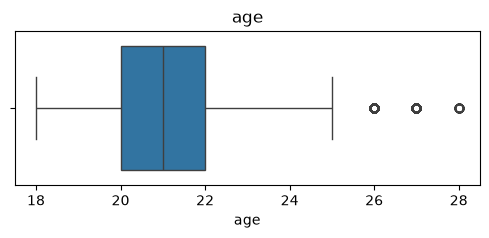

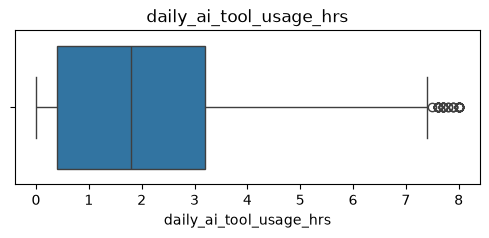

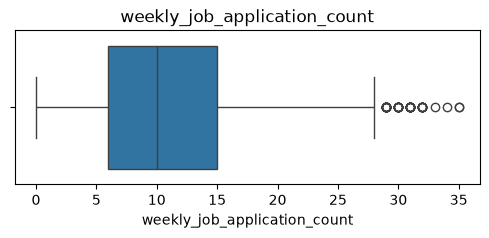

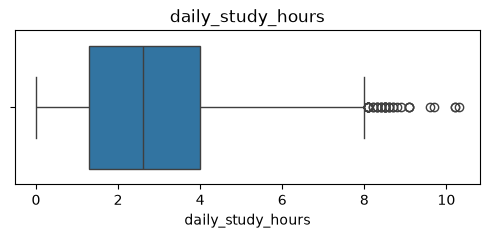

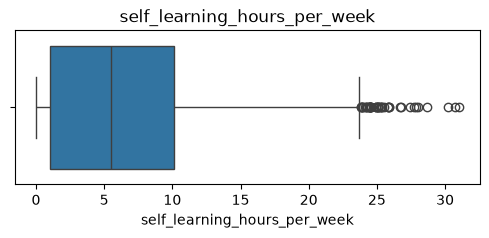

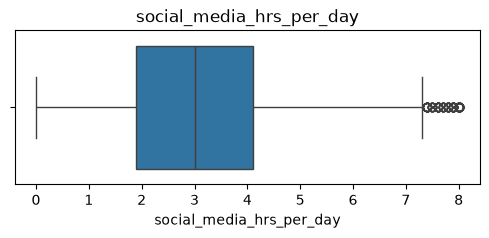

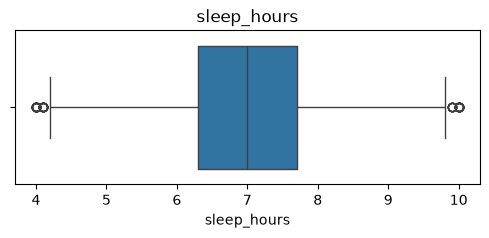

In [42]:
continuous_cols = [
    "age",
    "daily_ai_tool_usage_hrs",
    "weekly_job_application_count",
    "daily_study_hours",
    "self_learning_hours_per_week",
    "social_media_hrs_per_day",
    "sleep_hours"
]

for col in continuous_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

From these boxplots I do not see any point for concern.

Age: Although there are a few students aged 26-28, it is still realistic. These could be mature undergraduate students, graduate students, or students returning to school.

Daily AI Tool Usage: Numerous students use AI 7.5-8 hrs a day. This raises a bit of suspicion as it is high, however, it is justifiable as these could be students with more demanding majors using it to write code, reports, study, or even preparing for interviews.

Weekly Job Application Count: There are some students applying to 30-35 jobs a week. This is not concerning as students searching for jobs often submit multiple applications per day.

Daily Study Hours: Some students study 8-10 hours a day. This is high but plausible especially considering the demandng nature of some majors, exams, and projects. I am also curious whether lecture and lab times are cosnidered in this daily average. If so, this number would also be considered much more reasonable.

Self Learning Hours per Week: There are some students that self learn upwards of 30 hours each week. This is approximately 4-4.5 hours per day which is entirely possible for motivated students. Additionally, since one of my research questions is about highly-motivated students, it is counterintuitive to remove or impute these values.

Social Media Hours: Some students spend 7-8 hours on social media apps. This is high but not of concern, as this is a realistic occurence especially in a "doomscrolling" epidemic.

Sleep Hours: Some students sleep 4 hours. This is not concerning especially since these students may be the same ones that have high daily study hour numbers, social media hours, or self learning hours. It just implies sleep deprivation. On the other hand, there are students that sleep 10 hours. This is also plausible due to individual differences and different needs.

## Check for Duplicate Records

In [43]:
df.duplicated().sum()

np.int64(0)

There are no duplicate records.

## Closer Look at Variables

In [44]:
df.columns

Index(['student_id', 'age', 'gender', 'degree_type', 'stream', 'year_of_study',
       'college_tier', 'urban_or_rural', 'daily_ai_tool_usage_hrs',
       'primary_ai_tools_used', 'uses_ai_for_assignments',
       'ai_replaces_own_thinking_score', 'ai_dependency_score',
       'placement_anxiety_score', 'fear_of_job_loss_to_ai',
       'career_clarity_score', 'internship_experience',
       'weekly_job_application_count', 'resume_confidence_score',
       'interview_anxiety_score', 'daily_study_hours',
       'self_learning_hours_per_week', 'skill_development_courses_taken',
       'social_media_hrs_per_day', 'sleep_hours', 'stress_level',
       'burnout_score', 'motivation_score', 'seeks_career_counseling',
       'overall_career_readiness_score'],
      dtype='str')

### Study Area Distribution

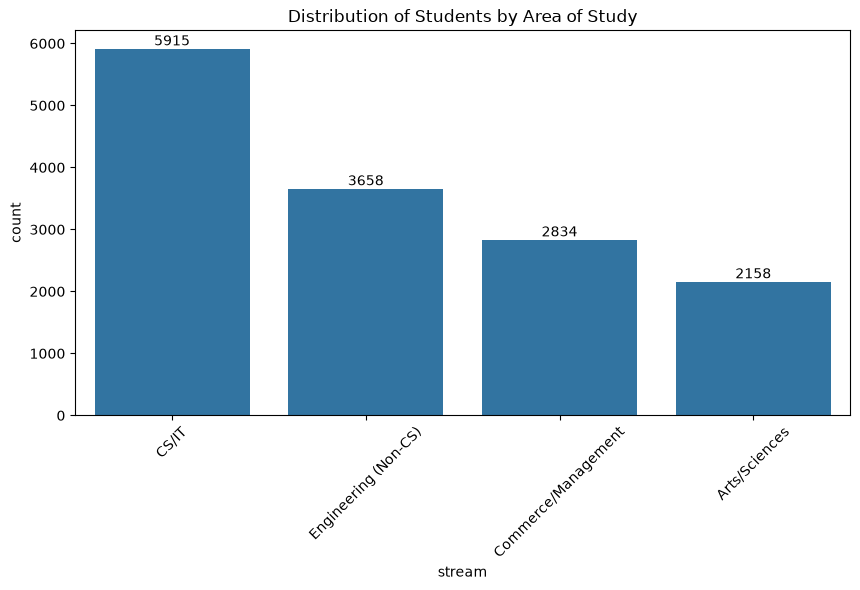

In [45]:
plt.figure(figsize=(10,5))

plot = sns.countplot(
    data=df,
    x="stream",
    order=df["stream"].value_counts().index
)

plot.bar_label(ax.containers[0])

plt.xticks(rotation=45)
plt.title("Distribution of Students by Area of Study")
plt.show()

Considering that the dataset consists of many different majors and disciplines, it is important to know whether it is balanced across these different areas of study.

Out of the 14,565 students observed, there are 5915 CS/IT majors (40.6%), 3658 Engineering (non-CS) majors (25.1%), 2834 Commerce/Management majors (19.5%), and 2158 Arts/Sciences majors (14.8%).

This means that the dataset is not balanced.

Going forward, it is important to consider this distribution when interpreting any results. Since CS/IT make up the greatest proportion of the dataset, trends may be more influenced by this group overall. Therefore, when investigating relationships between AI usage, career anxiety, and student habits, I will examine the overall dataset and each individual study discipline.

Additionally, I am not going to remove any records or balance the dataset. This is because each area of study still has a substantial amount of student records for decent comparisons. Instead, when needed, I will utilize percentages or other methods if and when needed, so that the comparisons drawn are not just based on the number of students in each group.

### AI Usage by Area of Study

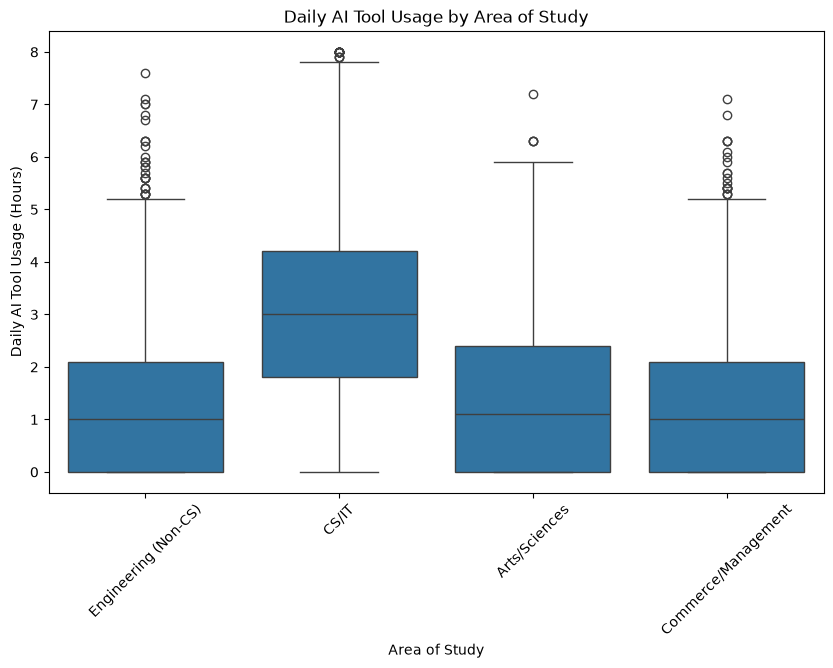

In [46]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="stream",
    y="daily_ai_tool_usage_hrs"
)

plt.xticks(rotation=45)
plt.title("Daily AI Tool Usage by Area of Study")
plt.xlabel("Area of Study")
plt.ylabel("Daily AI Tool Usage (Hours)")

plt.show()

The daily AI usage differs across the four areas of study. CS/IT students have the highest daily median with 3 hrs, while Engineering (non-cs), Arts/Sciences, and Commerce/Management all have a median of approximately 1 hr.

There are also some high usage students in each domain. Engineering and Commerce/Management both have numerous outliers ranging from approximately 5.5-7.5 hrs. Meanwhile, Arts/Sciences has 2 outliers ranging from 6-7 hrs. Lastly, CS/IT has 2 outliers ranging around 8 hrs of AI use per day.

These results ultimately suggest that AI use differs greatly amongst different majors. CS/IT students having a higher median is likely due to them using AI more for school work or to prepare for professional settings. They also have one of the most "computer-oriented" and technical majors, therefore, they may use AI to guide them through their processes more. Additionally, this does not necessarily mean that they are more dependent on AI, they simply use it more.

Additionally, it is also important to note that the dataset is imbalanced and due to this, we may see less variation in other streams (areas of study).

Lastly, this visualization only shows differences in AI usage and does not determine whether higher AI usage is associated with greater career anxiety. This will need to be explored more.

### Career Placement Anxiety by Area of Study

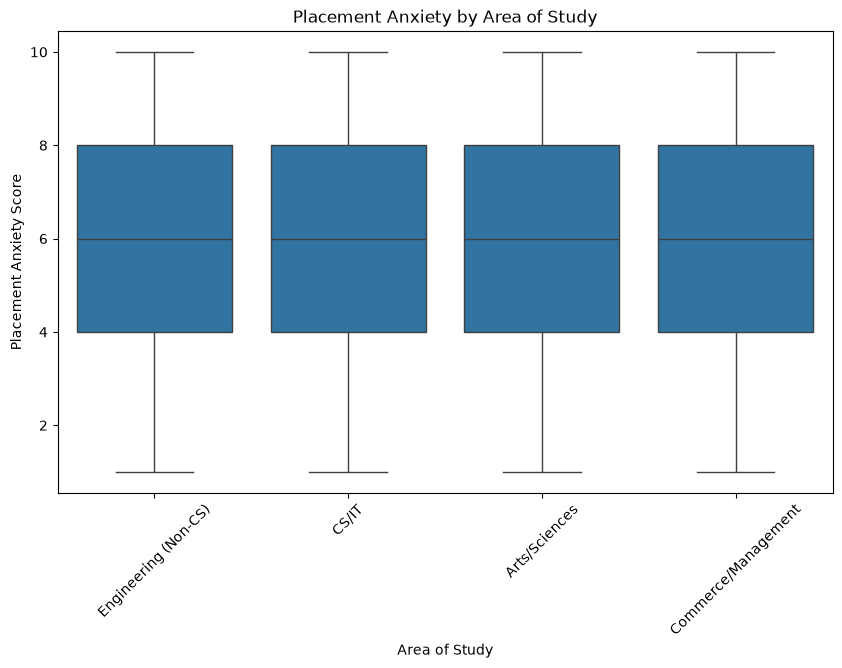

In [48]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="stream",
    y="placement_anxiety_score"
)

plt.xticks(rotation=45)
plt.title("Placement Anxiety by Area of Study")
plt.xlabel("Area of Study")
plt.ylabel("Placement Anxiety Score")

plt.show()

This is interesting as I would have expected some variation, however, placement anxiety appears to be similar amongst all four study disciplines. Each area of study has a median of approximately 6, and similar distribution shapes with no outliers.

This suggests that, from a macro-level, placement anxiety does not differ much between areas of study in this dataset

However, since the primary research question is regarding the relationship between AI usage and career anxiety, as the next step, I will compare AI usage with placement anxiety rather than only comparing anxiety between study disciplines.

### AI Usage vs Placement Anxiety

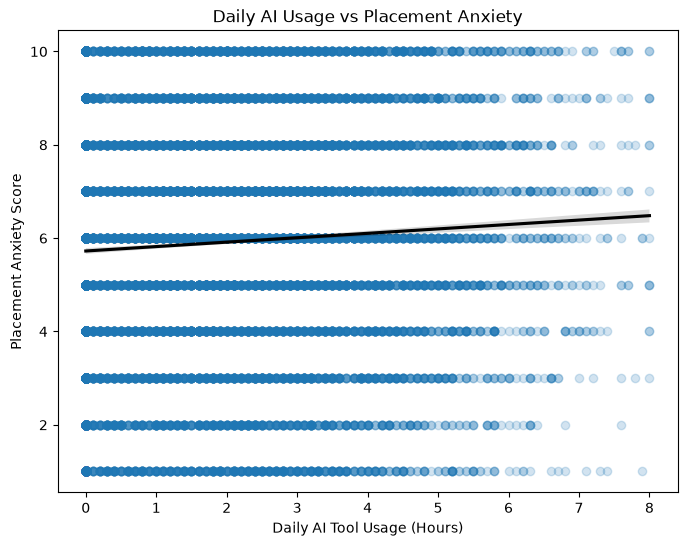

In [52]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="daily_ai_tool_usage_hrs",
    y="placement_anxiety_score",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "black"}
)

plt.title("Daily AI Usage vs Placement Anxiety")
plt.xlabel("Daily AI Tool Usage (Hours)")
plt.ylabel("Placement Anxiety Score")

plt.show()

### AI Usage vs Placement Anxiety by Study Area

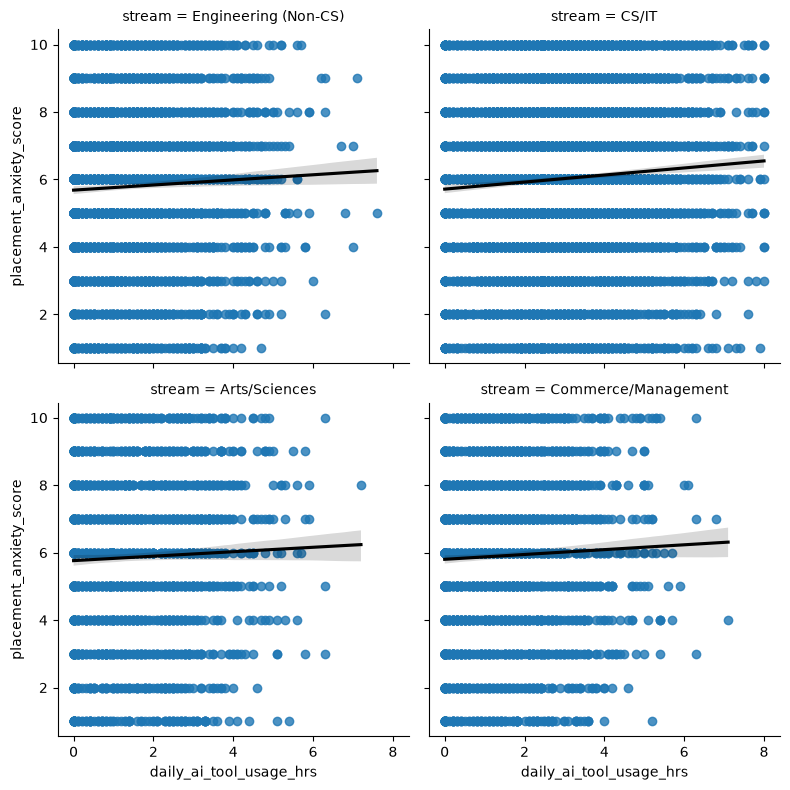

In [53]:
sns.lmplot(
    data=df,
    x="daily_ai_tool_usage_hrs",
    y="placement_anxiety_score",
    col="stream",
    col_wrap=2,
    height=4,
    line_kws={"color": "black"}
)

### Distribution of AI Usage`

<Axes: xlabel='ai_dependency_score', ylabel='Count'>

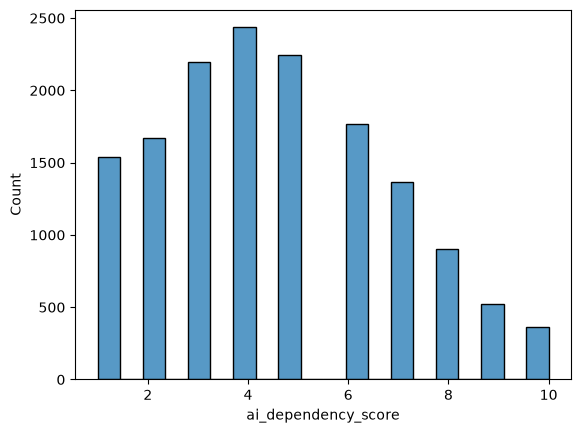

In [14]:
sns.histplot(df["ai_dependency_score"], bins=20)

### Distribution of Career Anxiety

<Axes: xlabel='placement_anxiety_score', ylabel='Count'>

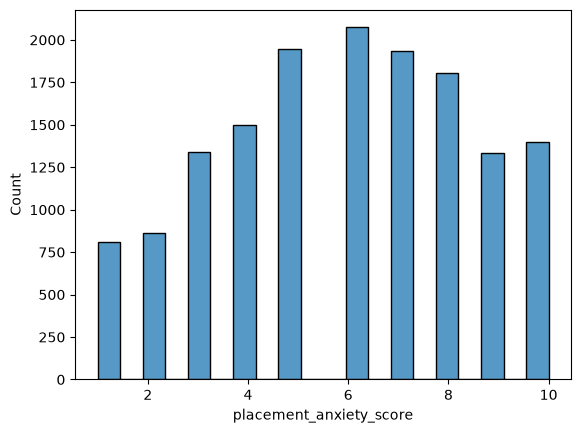

In [20]:
sns.histplot(df["placement_anxiety_score"], bins = 20)

### Correlation Matrix (Relationships Between Variables)

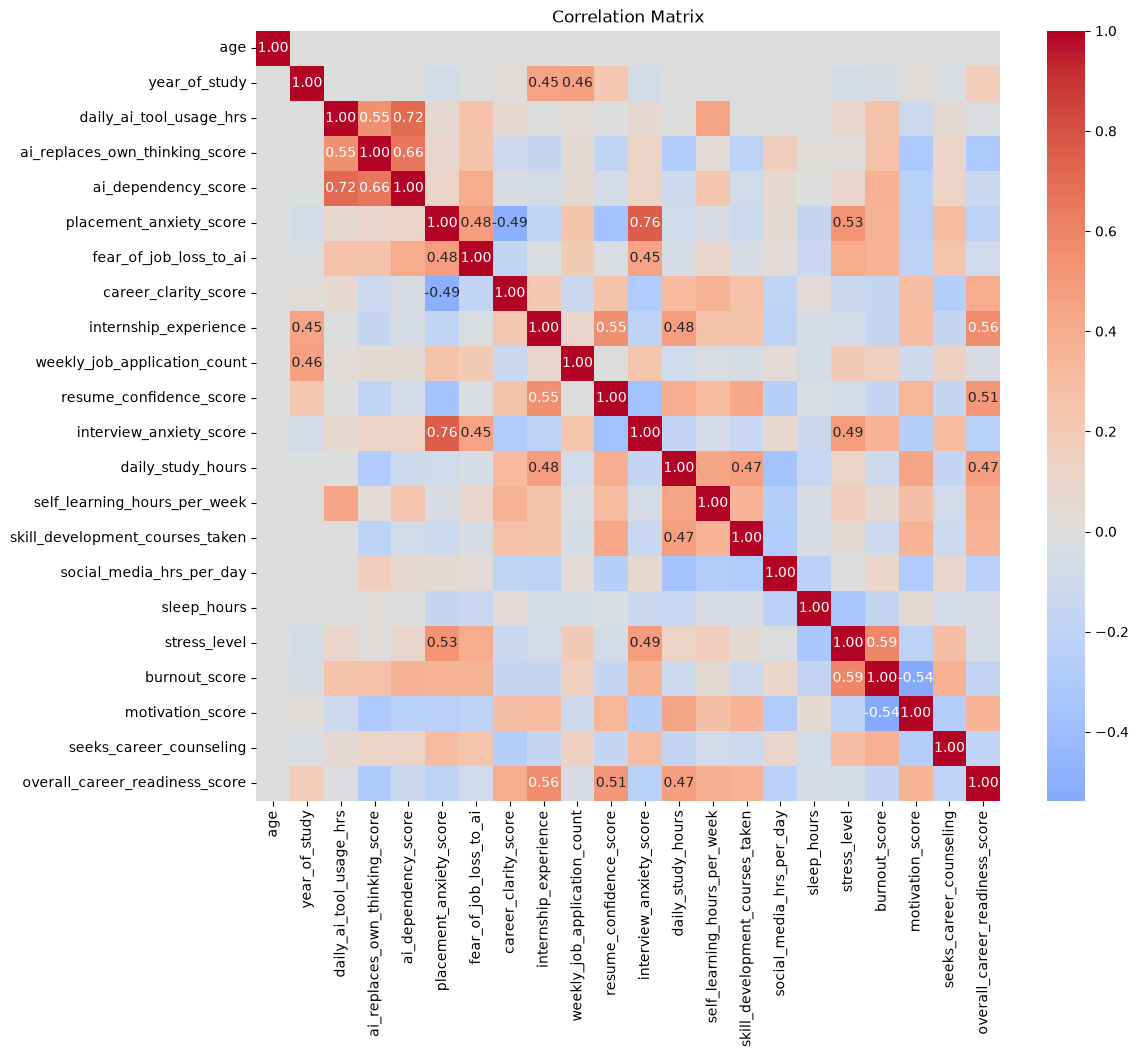

In [26]:
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()
labels = corr.map(lambda v: f"{v:.2f}" if abs(v) > 0.45 else "")

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=labels,
    fmt=""
)

plt.title("Correlation Matrix")
plt.show()